Parsed deterministic rows: 1000
Parsed Sto-SQP rows: 1000
Deterministic iteration range: 10 to 10000
Sto-SQP iteration range: 10 to 10000


Saved: allen_cahn_main_mse_full_trajectory.png
Saved: allen_cahn_main_mse_full_trajectory.pdf


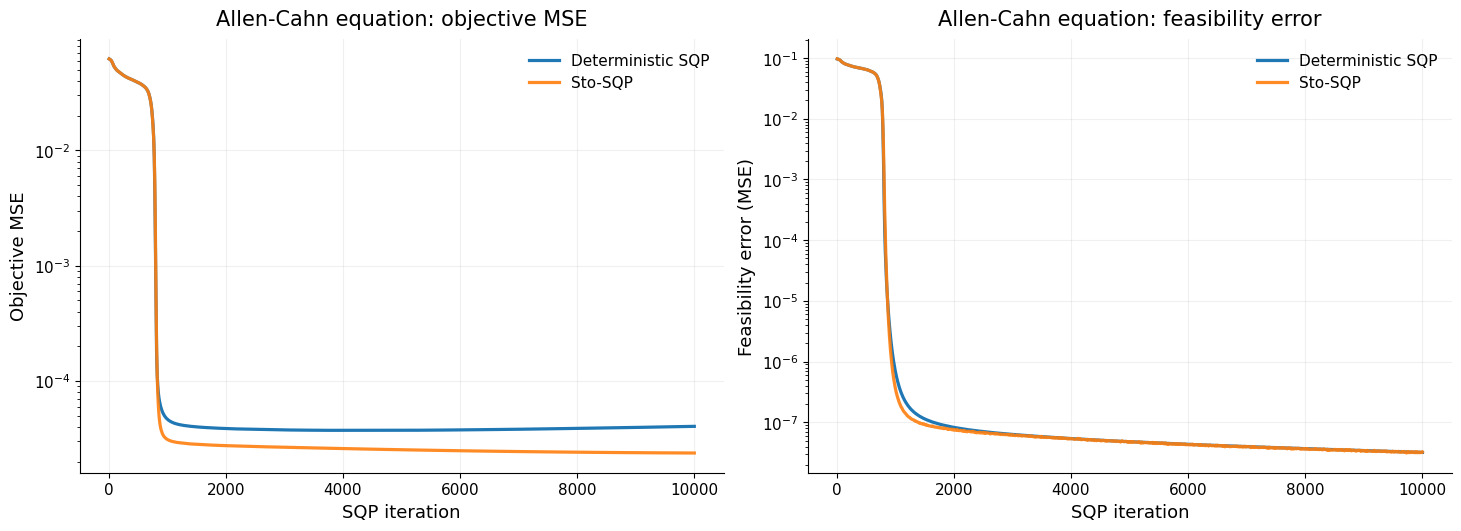

Saved: allen_cahn_constraint_components_mse_full_trajectory.png
Saved: allen_cahn_constraint_components_mse_full_trajectory.pdf


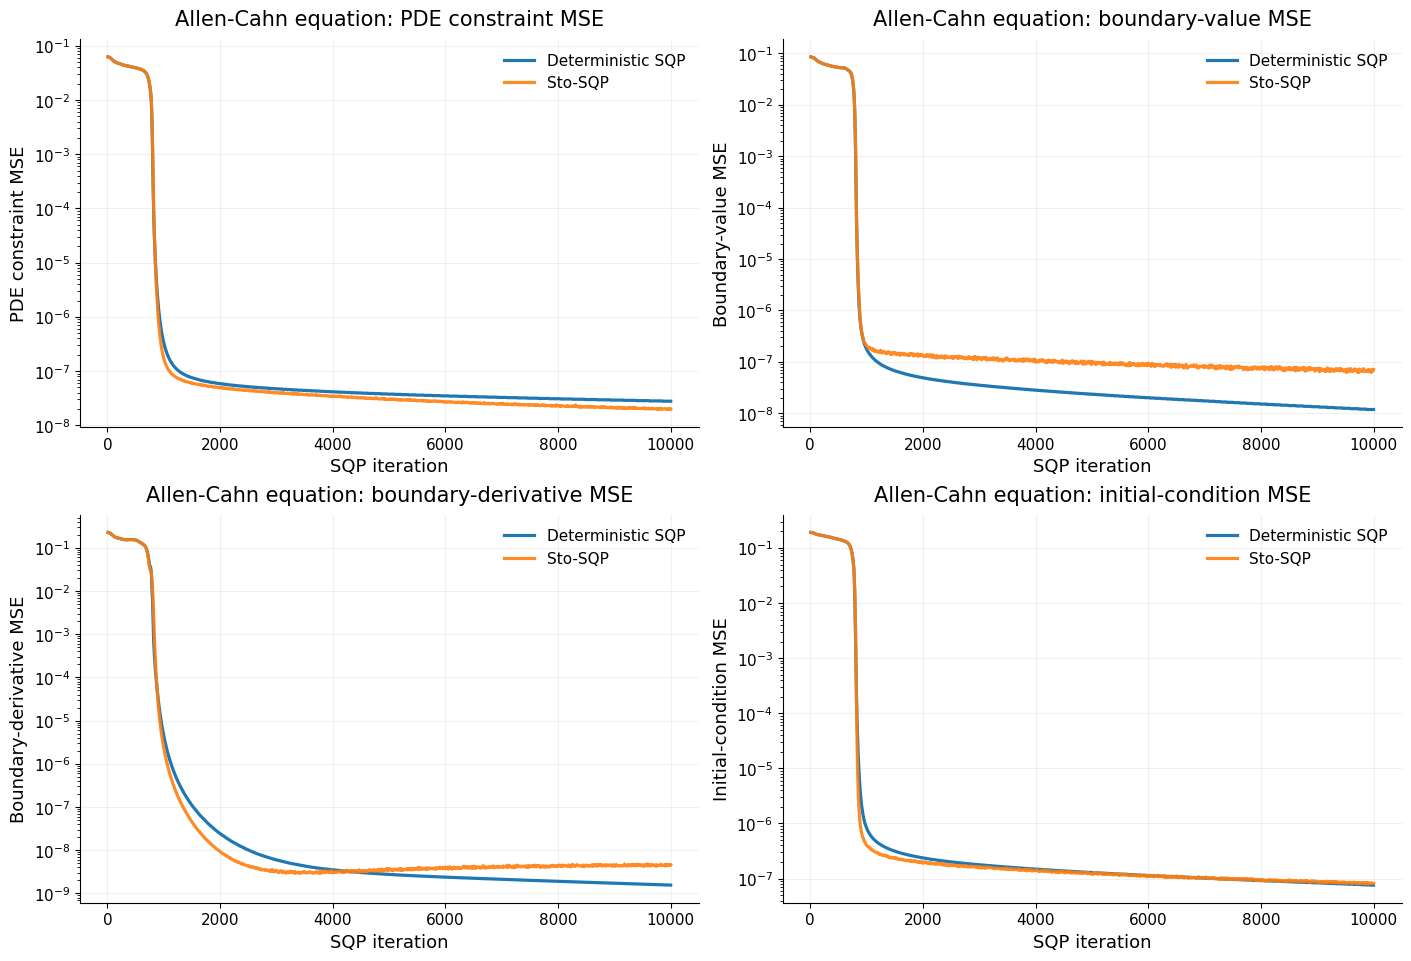

Saved: allen_cahn_stosqp_constraint_components_full_trajectory.png
Saved: allen_cahn_stosqp_constraint_components_full_trajectory.pdf


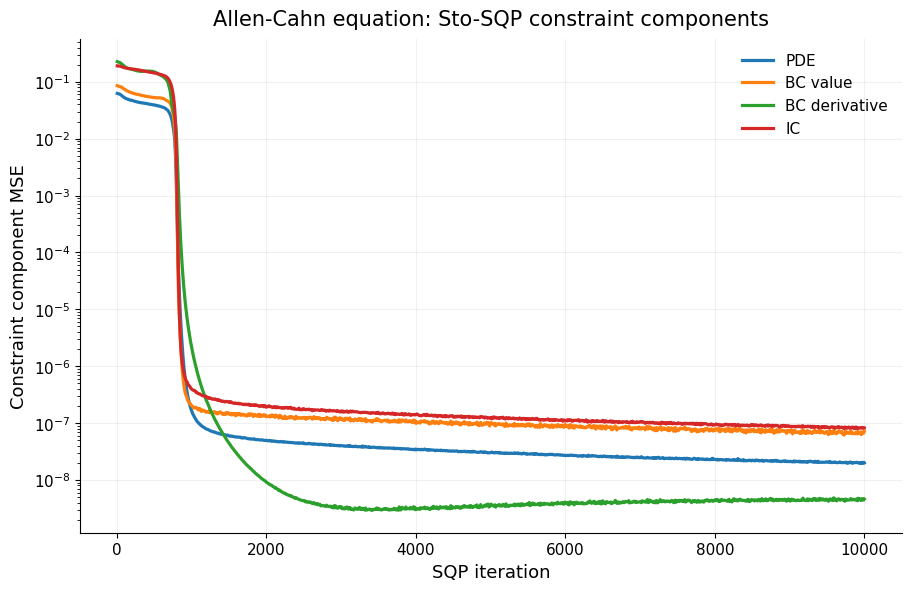

Saved: allen_cahn_deterministic_sqp_constraint_components_full_trajectory.png
Saved: allen_cahn_deterministic_sqp_constraint_components_full_trajectory.pdf


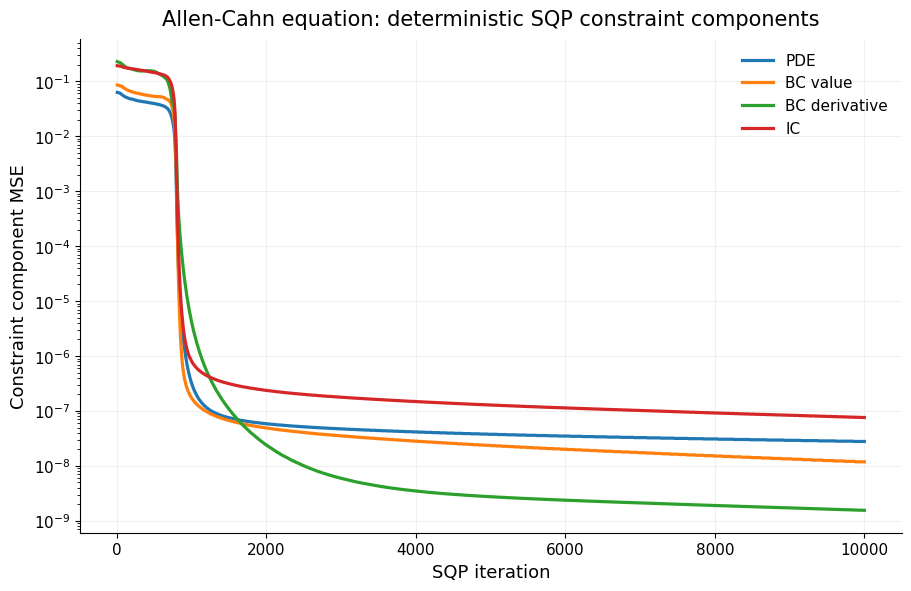

Saved: allen_cahn_relL2_full_trajectory.png
Saved: allen_cahn_relL2_full_trajectory.pdf


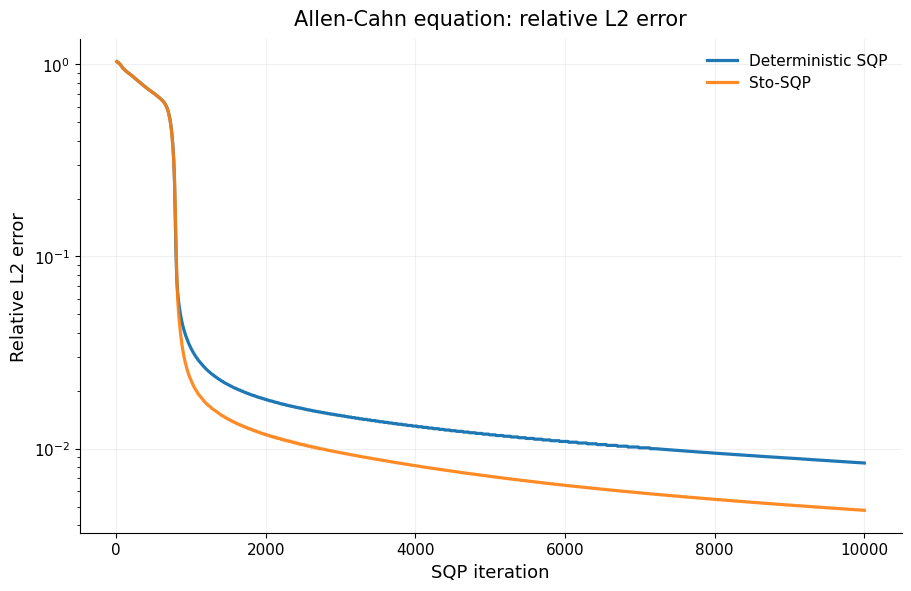


Done.
Main files:
  allen_cahn_main_mse_full_trajectory.png
  allen_cahn_main_mse_full_trajectory.pdf
  allen_cahn_constraint_components_mse_full_trajectory.png
  allen_cahn_constraint_components_mse_full_trajectory.pdf
  allen_cahn_stosqp_constraint_components_full_trajectory.png
  allen_cahn_stosqp_constraint_components_full_trajectory.pdf
  allen_cahn_deterministic_sqp_constraint_components_full_trajectory.png
  allen_cahn_deterministic_sqp_constraint_components_full_trajectory.pdf
  allen_cahn_relL2_full_trajectory.png
  allen_cahn_relL2_full_trajectory.pdf


In [4]:
from pathlib import Path
import re
import csv
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# User settings
# ============================================================
sto_path = Path("ac_sto.txt")        # Sto-SQP Allen-Cahn log
det_path = Path("ac_deter.txt")    # deterministic SQP Allen-Cahn log

eq_name = "Allen-Cahn equation"
OUT_DIR = Path(".")

# In your Allen-Cahn table:
#   obj    = weighted/scaled objective printed by code
#   pdeMSE = PDE objective MSE printed separately
# For plotting objective MSE, use pdeMSE directly.


# ============================================================
# Parser for Allen-Cahn table logs
# ============================================================
def parse_allen_cahn_log(path):
    text = path.read_text(errors="ignore")
    rows = []

    # Table row example:
    #  1000 |  3.122e-04 |  3.120e-05 |  3.722e-07 |  4.12e-04 | ...
    row_pattern = re.compile(
        r"^\s*"
        r"(?P<iter>\d+)\s*\|\s*"
        r"(?P<obj>[+-]?\d+(?:\.\d+)?e[+-]?\d+)\s*\|\s*"
        r"(?P<pdeMSE>[+-]?\d+(?:\.\d+)?e[+-]?\d+)\s*\|\s*"
        r"(?P<feas>[+-]?\d+(?:\.\d+)?e[+-]?\d+)\s*\|\s*"
        r"(?P<PDE>[+-]?\d+(?:\.\d+)?e[+-]?\d+)\s*\|\s*"
        r"(?P<BCv>[+-]?\d+(?:\.\d+)?e[+-]?\d+)\s*\|\s*"
        r"(?P<BCd>[+-]?\d+(?:\.\d+)?e[+-]?\d+)\s*\|\s*"
        r"(?P<IC>[+-]?\d+(?:\.\d+)?e[+-]?\d+)\s*\|\s*"
        r"(?P<stat>[+-]?\d+(?:\.\d+)?e[+-]?\d+)\s*\|\s*"
        r"(?P<alpha>[+-]?\d+(?:\.\d+)?e[+-]?\d+)\s*\|\s*"
        r"(?P<stepInf>[+-]?\d+(?:\.\d+)?e[+-]?\d+)\s*\|\s*"
        r"(?P<lam>[+-]?\d+(?:\.\d+)?e[+-]?\d+)\s*\|\s*"
        r"(?P<kkt>[+-]?\d+(?:\.\d+)?e[+-]?\d+)\s*\|\s*"
        r"(?P<relL2>[+-]?\d+(?:\.\d+)?e[+-]?\d+)\s*\|\s*"
        r"(?P<tau>[+-]?\d+(?:\.\d+)?e[+-]?\d+)"
    )

    for line in text.splitlines():
        m = row_pattern.match(line)
        if not m:
            continue

        d = m.groupdict()

        pde_rms = float(d["PDE"])
        bcv_rms = float(d["BCv"])
        bcd_rms = float(d["BCd"])
        ic_rms  = float(d["IC"])

        rows.append({
            "iter": int(d["iter"]),

            # main quantities
            "obj_printed": float(d["obj"]),
            "obj_mse": float(d["pdeMSE"]),
            "feas_mse": float(d["feas"]),

            # constraint component MSEs
            # table columns PDE/BCv/BCd/IC are RMS-like values,
            # so square them for MSE plots
            "pde_con_mse": pde_rms ** 2,
            "bcv_mse": bcv_rms ** 2,
            "bcd_mse": bcd_rms ** 2,
            "ic_mse": ic_rms ** 2,

            # optional diagnostics
            "pde_rms": pde_rms,
            "bcv_rms": bcv_rms,
            "bcd_rms": bcd_rms,
            "ic_rms": ic_rms,
            "station": float(d["stat"]),
            "alpha": float(d["alpha"]),
            "step_inf": float(d["stepInf"]),
            "lambda": float(d["lam"]),
            "kkt": float(d["kkt"]),
            "relL2": float(d["relL2"]),
            "tau": float(d["tau"]),
        })

    rows = sorted(rows, key=lambda r: r["iter"])

    # remove duplicate iteration rows if output pasted twice
    dedup = {}
    for r in rows:
        dedup[r["iter"]] = r

    return list(dedup.values())


# ============================================================
# Load logs
# ============================================================
det_rows = parse_allen_cahn_log(det_path)
sto_rows = parse_allen_cahn_log(sto_path)

if len(det_rows) == 0:
    raise RuntimeError(f"No Allen-Cahn iteration rows parsed from {det_path}")
if len(sto_rows) == 0:
    raise RuntimeError(f"No Allen-Cahn iteration rows parsed from {sto_path}")

print("Parsed deterministic rows:", len(det_rows))
print("Parsed Sto-SQP rows:", len(sto_rows))
print("Deterministic iteration range:", det_rows[0]["iter"], "to", det_rows[-1]["iter"])
print("Sto-SQP iteration range:", sto_rows[0]["iter"], "to", sto_rows[-1]["iter"])


# ============================================================
# Save parsed CSV
# ============================================================
def save_csv(rows, filename):
    fieldnames = list(rows[0].keys())
    with open(filename, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

save_csv(det_rows, OUT_DIR / "allen_cahn_det_sqp_fulltraj_parsed.csv")
save_csv(sto_rows, OUT_DIR / "allen_cahn_sto_sqp_fulltraj_parsed.csv")


# ============================================================
# Helpers
# ============================================================
def col(rows, key):
    return np.array([r[key] for r in rows], dtype=float)

det_iter = col(det_rows, "iter")
sto_iter = col(sto_rows, "iter")


# ============================================================
# Plot style
# ============================================================
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2.3,
})


def beautify_axis(ax, xlabel, ylabel, title):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=10)
    ax.set_yscale("log")

    # cleaner grid
    ax.grid(True, which="major", alpha=0.18, linewidth=0.8)
    ax.grid(False, which="minor")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def savefig(fig, basename):
    png = OUT_DIR / f"{basename}.png"
    pdf = OUT_DIR / f"{basename}.pdf"

    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")

    print("Saved:", png)
    print("Saved:", pdf)


# ============================================================
# Figure 1: main full-trajectory plot
# Objective MSE + Feasibility error MSE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2), constrained_layout=True)

axes[0].plot(det_iter, col(det_rows, "obj_mse"), label="Deterministic SQP")
axes[0].plot(sto_iter, col(sto_rows, "obj_mse"), label="Sto-SQP", alpha=0.90)
beautify_axis(
    axes[0],
    "SQP iteration",
    "Objective MSE",
    f"{eq_name}: objective MSE",
)
axes[0].legend(frameon=False)

axes[1].plot(det_iter, col(det_rows, "feas_mse"), label="Deterministic SQP")
axes[1].plot(sto_iter, col(sto_rows, "feas_mse"), label="Sto-SQP", alpha=0.90)
beautify_axis(
    axes[1],
    "SQP iteration",
    "Feasibility error (MSE)",
    f"{eq_name}: feasibility error",
)
axes[1].legend(frameon=False)

savefig(fig, "allen_cahn_main_mse_full_trajectory")
plt.show()


# ============================================================
# Figure 2: full-trajectory constraint component MSEs
# ============================================================
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 9.5), constrained_layout=True)

panels = [
    ("pde_con_mse", "PDE constraint MSE", f"{eq_name}: PDE constraint MSE"),
    ("bcv_mse", "Boundary-value MSE", f"{eq_name}: boundary-value MSE"),
    ("bcd_mse", "Boundary-derivative MSE", f"{eq_name}: boundary-derivative MSE"),
    ("ic_mse", "Initial-condition MSE", f"{eq_name}: initial-condition MSE"),
]

for ax, (key, ylabel, title) in zip(axes2.ravel(), panels):
    ax.plot(det_iter, col(det_rows, key), label="Deterministic SQP")
    ax.plot(sto_iter, col(sto_rows, key), label="Sto-SQP", alpha=0.90)
    beautify_axis(ax, "SQP iteration", ylabel, title)
    ax.legend(frameon=False)

savefig(fig2, "allen_cahn_constraint_components_mse_full_trajectory")
plt.show()


# ============================================================
# Figure 3: Sto-SQP component overlay, full trajectory
# ============================================================
fig3, ax3 = plt.subplots(figsize=(9, 5.8), constrained_layout=True)

ax3.plot(sto_iter, col(sto_rows, "pde_con_mse"), label="PDE")
ax3.plot(sto_iter, col(sto_rows, "bcv_mse"), label="BC value")
ax3.plot(sto_iter, col(sto_rows, "bcd_mse"), label="BC derivative")
ax3.plot(sto_iter, col(sto_rows, "ic_mse"), label="IC")

beautify_axis(
    ax3,
    "SQP iteration",
    "Constraint component MSE",
    f"{eq_name}: Sto-SQP constraint components",
)
ax3.legend(frameon=False)

savefig(fig3, "allen_cahn_stosqp_constraint_components_full_trajectory")
plt.show()


# ============================================================
# Figure 4: Deterministic SQP component overlay, full trajectory
# ============================================================
fig4, ax4 = plt.subplots(figsize=(9, 5.8), constrained_layout=True)

ax4.plot(det_iter, col(det_rows, "pde_con_mse"), label="PDE")
ax4.plot(det_iter, col(det_rows, "bcv_mse"), label="BC value")
ax4.plot(det_iter, col(det_rows, "bcd_mse"), label="BC derivative")
ax4.plot(det_iter, col(det_rows, "ic_mse"), label="IC")

beautify_axis(
    ax4,
    "SQP iteration",
    "Constraint component MSE",
    f"{eq_name}: deterministic SQP constraint components",
)
ax4.legend(frameon=False)

savefig(fig4, "allen_cahn_deterministic_sqp_constraint_components_full_trajectory")
plt.show()


# ============================================================
# Optional Figure 5: relative L2 trajectory
# ============================================================
fig5, ax5 = plt.subplots(figsize=(9, 5.8), constrained_layout=True)

ax5.plot(det_iter, col(det_rows, "relL2"), label="Deterministic SQP")
ax5.plot(sto_iter, col(sto_rows, "relL2"), label="Sto-SQP", alpha=0.90)

beautify_axis(
    ax5,
    "SQP iteration",
    "Relative L2 error",
    f"{eq_name}: relative L2 error",
)
ax5.legend(frameon=False)

savefig(fig5, "allen_cahn_relL2_full_trajectory")
plt.show()


print("\nDone.")
print("Main files:")
print("  allen_cahn_main_mse_full_trajectory.png")
print("  allen_cahn_main_mse_full_trajectory.pdf")
print("  allen_cahn_constraint_components_mse_full_trajectory.png")
print("  allen_cahn_constraint_components_mse_full_trajectory.pdf")
print("  allen_cahn_stosqp_constraint_components_full_trajectory.png")
print("  allen_cahn_stosqp_constraint_components_full_trajectory.pdf")
print("  allen_cahn_deterministic_sqp_constraint_components_full_trajectory.png")
print("  allen_cahn_deterministic_sqp_constraint_components_full_trajectory.pdf")
print("  allen_cahn_relL2_full_trajectory.png")
print("  allen_cahn_relL2_full_trajectory.pdf")